# Session 4 Lecture/Lab: Feature extraction and segmentation


In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

## **1) Edge detection**

In [2]:
img1=files.upload()

Saving animals.jpeg to animals.jpeg
Saving ChessBoard.png to ChessBoard.png
Saving coins.jpeg to coins.jpeg
Saving edgedetection.png to edgedetection.png
Saving euro_coins_mix.jpg to euro_coins_mix.jpg
Saving eye.jpg to eye.jpg
Saving fruits_color.png to fruits_color.png
Saving girafe_shadow.jpeg to girafe_shadow.jpeg
Saving grass.jpeg to grass.jpeg
Saving gravel.jpeg to gravel.jpeg
Saving Lena.png to Lena.png
Saving moon.jpg to moon.jpg
Saving ocean_colors.jpeg to ocean_colors.jpeg
Saving rotated_letters.png to rotated_letters.png
Saving shapes.png to shapes.png
Saving shapes_donut.png to shapes_donut.png
Saving sudoku.jpg to sudoku.jpg
Saving sudoku.png to sudoku.png
Saving sunset.jpg to sunset.jpg
Saving taj_noise.jpg to taj_noise.jpg
Saving tomatoes_colors.png to tomatoes_colors.png
Saving Tour_Eiffel.jpg to Tour_Eiffel.jpg
Saving wall.jpeg to wall.jpeg
Saving zidane_couleur.png to zidane_couleur.png


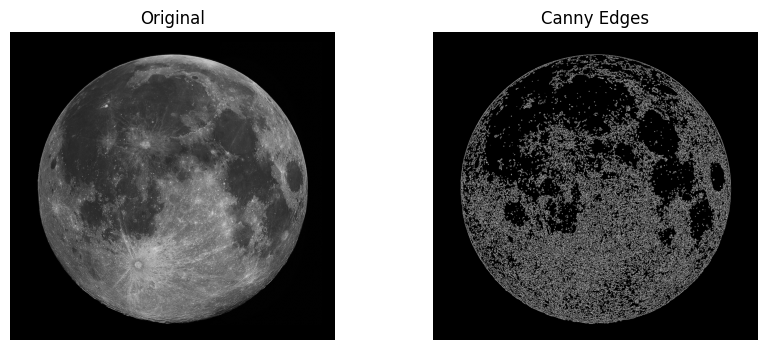

In [3]:
img = cv2.imread('moon.jpg',cv2.IMREAD_GRAYSCALE)

# Apply Canny edge detector
edges = cv2.Canny(img, 100, 200)
# Show original and edge-detected image side by side
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')
plt.show()

## **1.2) Harris corner detection**

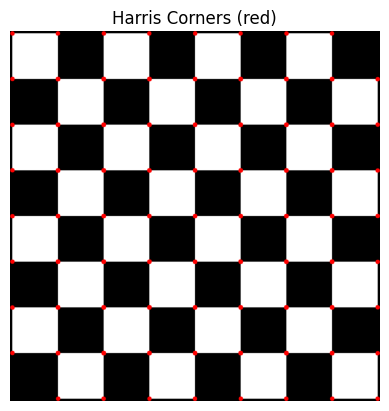

In [4]:
# Reading the image and converting the image to B/W
image = cv2.imread('ChessBoard.png')
gray = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2GRAY)
# Harris corner detection
img_float = np.float32(gray)
dst = cv2.cornerHarris(img_float, blockSize=2, ksize=3, k=0.04)

# Corner responses are often very “sharp” and isolated: just a single bright pixel for each corner.
# cv2.dilate(dst, None) expands (“fattens”) each bright spot in the response map.
#This makes corners easier to see

dst = cv2.dilate(dst, None)

# Get corners

corners = np.argwhere(dst > 0.001 * dst.max())

for y, x in corners:  # Note: np.argwhere returns (row, col) = (y, x)
    cv2.circle(image, (x, y), radius=10, color=(0,0,255), thickness=-1)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners (red)')
plt.axis('off')
plt.show()


## **2) Texture features**
### **2.1) Local Binary Patterns**


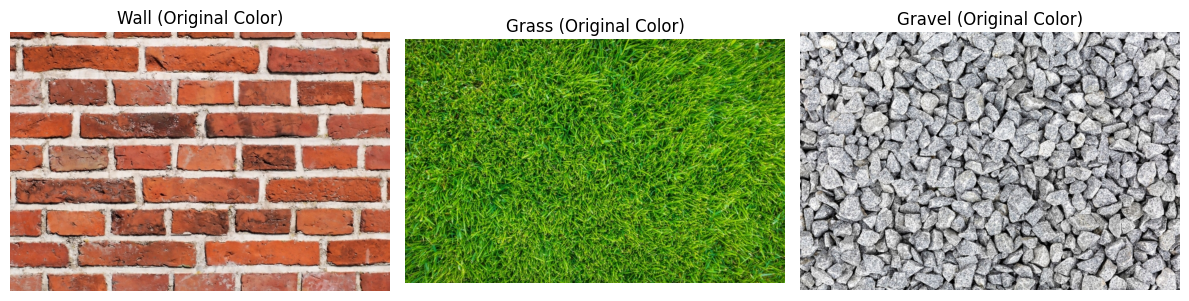

In [5]:
img_wall = cv2.imread('wall.jpeg')
img_wall_rgb = cv2.cvtColor(img_wall, cv2.COLOR_BGR2RGB)
img_grass = cv2.imread('grass.jpeg')
img_grass_rgb = cv2.cvtColor(img_grass, cv2.COLOR_BGR2RGB)
img_gravel = cv2.imread('gravel.jpeg')
img_gravel_rgb = cv2.cvtColor(img_gravel, cv2.COLOR_BGR2RGB)



plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_wall_rgb)
plt.title('Wall (Original Color)')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(img_grass_rgb)
plt.title('Grass (Original Color)')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(img_gravel_rgb)
plt.title('Gravel (Original Color)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
#Convert to grayscale for LBP
img_wall_gray = cv2.cvtColor(img_wall, cv2.COLOR_BGR2GRAY)
img_grass_gray = cv2.cvtColor(img_grass, cv2.COLOR_BGR2GRAY)
img_gravel_gray = cv2.cvtColor(img_gravel, cv2.COLOR_BGR2GRAY)

# LBP parameters
P = 8   # Number of neighbors
R = 1   # Radius
METHOD = 'default'

# Compute LBP
from skimage.feature import local_binary_pattern

lbp_wall = local_binary_pattern(img_wall_gray, P, R, METHOD)
lbp_grass = local_binary_pattern(img_grass_gray, P, R, METHOD)
lbp_gravel = local_binary_pattern(img_gravel_gray, P, R, METHOD)


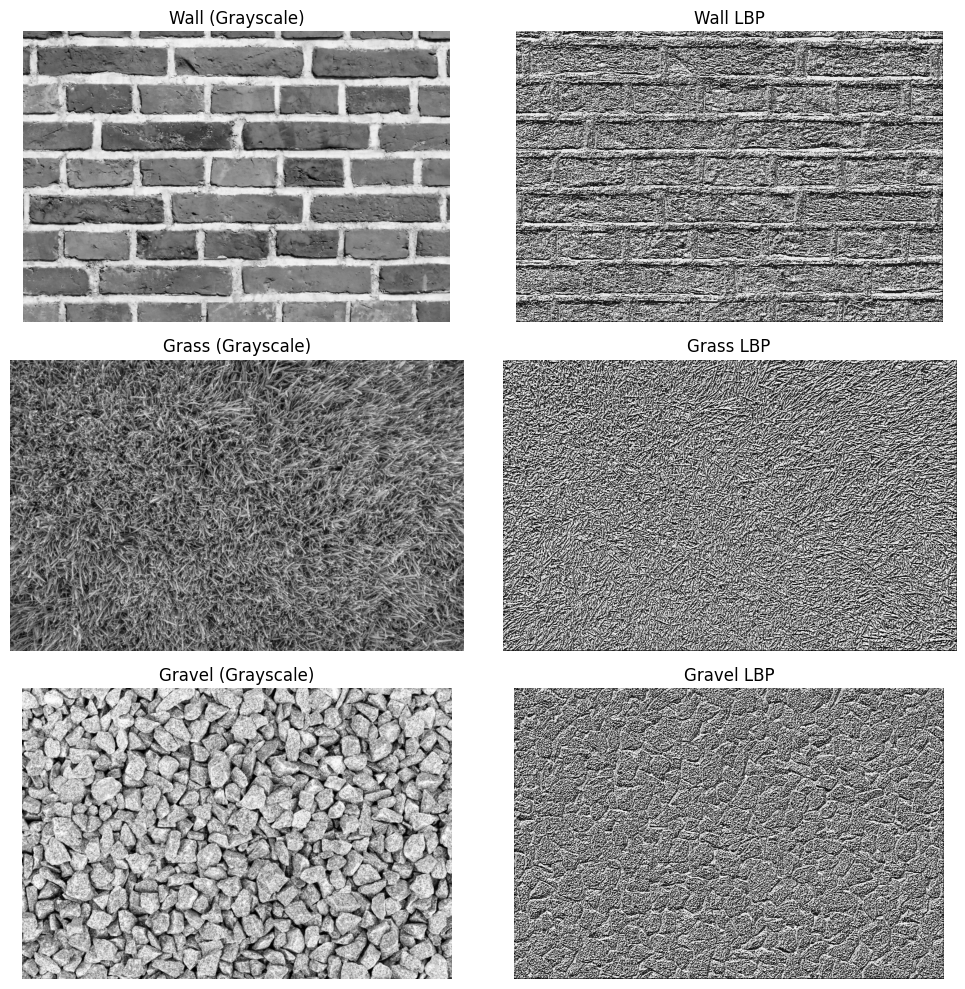

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes[0,0].imshow(img_wall_gray, cmap='gray');    axes[0,0].set_title('Wall (Grayscale)');    axes[0,0].axis('off')
axes[0,1].imshow(lbp_wall, cmap='gray');         axes[0,1].set_title('Wall LBP');            axes[0,1].axis('off')
axes[1,0].imshow(img_grass_gray, cmap='gray');   axes[1,0].set_title('Grass (Grayscale)');   axes[1,0].axis('off')
axes[1,1].imshow(lbp_grass, cmap='gray');        axes[1,1].set_title('Grass LBP');           axes[1,1].axis('off')
axes[2,0].imshow(img_gravel_gray, cmap='gray');  axes[2,0].set_title('Gravel (Grayscale)');  axes[2,0].axis('off')
axes[2,1].imshow(lbp_gravel, cmap='gray');       axes[2,1].set_title('Gravel LBP');          axes[2,1].axis('off')
plt.tight_layout()
plt.show()


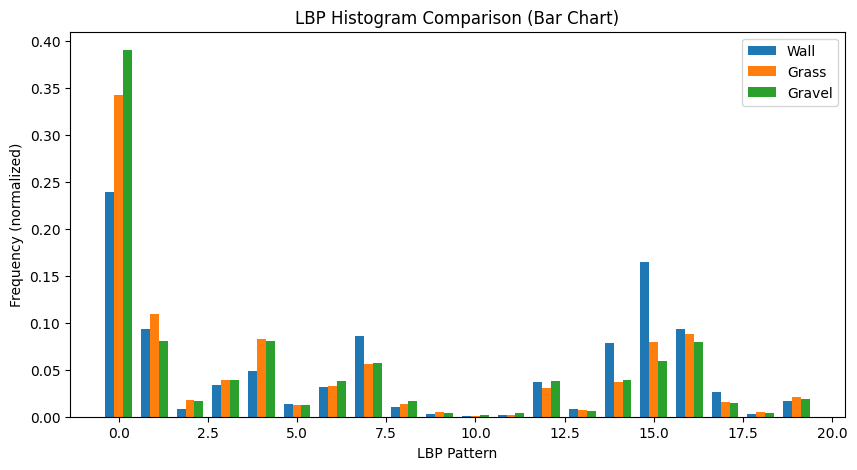

In [8]:
# Compute normalized histograms for comparison to extract features
n_bins = 20#int(max(lbp_wall.max(), lbp_grass.max(), lbp_gravel.max()) + 1)
hist_wall, _ = np.histogram(lbp_wall.ravel(), bins=n_bins, range=(0, n_bins), density=True)
hist_grass, _ = np.histogram(lbp_grass.ravel(), bins=n_bins, range=(0, n_bins), density=True)
hist_gravel, _ = np.histogram(lbp_gravel.ravel(), bins=n_bins, range=(0, n_bins), density=True)

x = np.arange(n_bins)
bar_width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - bar_width, hist_wall, width=bar_width, label='Wall')
plt.bar(x,  hist_grass, width=bar_width, label='Grass')
plt.bar(x + bar_width, hist_gravel, width=bar_width, label='Gravel')
plt.title('LBP Histogram Comparison (Bar Chart)')
plt.xlabel('LBP Pattern')
plt.ylabel('Frequency (normalized)')
plt.legend()
plt.show()

LBP is great for detecting differences in micro-texture (at a 3×3 pixel neighborhood for P=8, R=1).
For more complex or coarser textures, increase P and R.
Also, combining LBP with other texture features (like Haralick) is often necessary in real-world ML.

###**2.2) Haralick Features**

In [9]:
from skimage.feature import graycomatrix, graycoprops

# Convert images to grayscale and 8-bit if not already
img_wall_gray8 = cv2.normalize(img_wall_gray, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
img_grass_gray8 = cv2.normalize(img_grass_gray, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
img_gravel_gray8 = cv2.normalize(img_gravel_gray, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

# Compute GLCM (distance=1, angle=0°)
def get_haralick(img):
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    features = {
        'contrast':    graycoprops(glcm, 'contrast')[0, 0],
        'correlation': graycoprops(glcm, 'correlation')[0, 0],
        'energy':      graycoprops(glcm, 'energy')[0, 0],
        'homogeneity': graycoprops(glcm, 'homogeneity')[0, 0]
    }
    return features

feat_wall = get_haralick(img_wall_gray8)
feat_grass = get_haralick(img_grass_gray8)
feat_gravel = get_haralick(img_gravel_gray8)

# Display as a table
import pandas as pd

df = pd.DataFrame([feat_wall, feat_grass, feat_gravel],
                  index=['Wall', 'Grass', 'Gravel'])
print(df)

           contrast  correlation    energy  homogeneity
Wall     193.778556     0.965642  0.021114     0.211863
Grass   1211.565395     0.678868  0.009068     0.051666
Gravel  1311.460808     0.826269  0.007277     0.045373


###**2.3) Gabor filter**

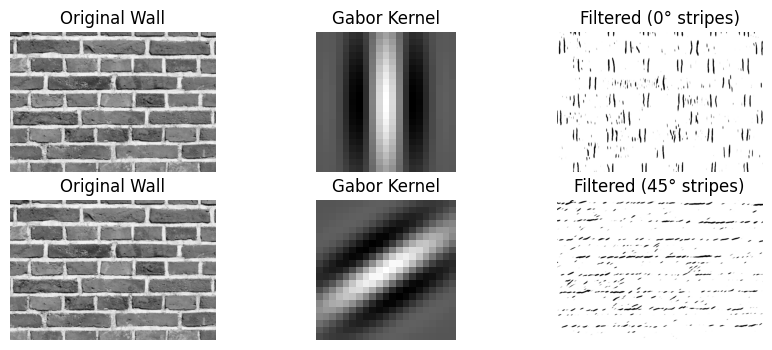

In [10]:
ksize = 21
theta = 0 # 0 = horizontal stripes
gabor_kernel_0 = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta, lambd=10.0, gamma=0.5, psi=0)
img_filt_0 = cv2.filter2D(img_wall_gray, cv2.CV_8UC3, gabor_kernel_0)

theta = 45 #
gabor_kernel_45 = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta, lambd=10.0, gamma=0.5, psi=0)
img_filt_45 = cv2.filter2D(img_wall_gray, cv2.CV_8UC3, gabor_kernel_45)


plt.figure(figsize=(10,4))
plt.subplot(2,3,1)
plt.imshow(img_wall_gray, cmap='gray')
plt.title('Original Wall')
plt.axis('off')
plt.subplot(2,3,2)
plt.imshow(gabor_kernel_0, cmap='gray')
plt.title('Gabor Kernel')
plt.axis('off')
plt.subplot(2,3,3)
plt.imshow(img_filt_0, cmap='gray')
plt.title('Filtered (0° stripes)')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(img_wall_gray, cmap='gray')
plt.title('Original Wall')
plt.axis('off')
plt.subplot(2,3,5)
plt.imshow(gabor_kernel_45, cmap='gray')
plt.title('Gabor Kernel')
plt.axis('off')
plt.subplot(2,3,6)
plt.imshow(img_filt_45, cmap='gray')
plt.title('Filtered (45° stripes)')
plt.axis('off')
plt.show()

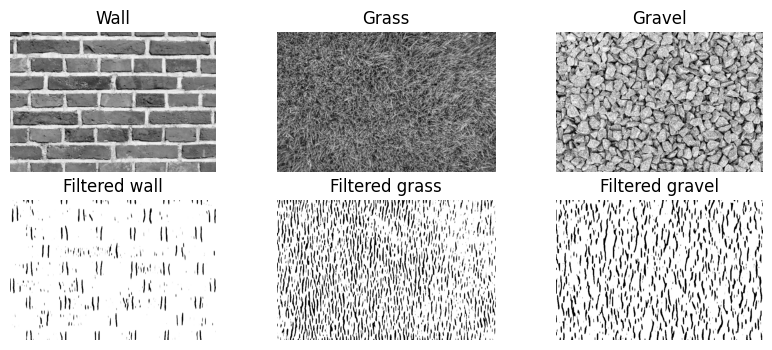

In [11]:
ksize = 21
theta = 0 # 0 = horizontal stripes
gabor_kernel_0 = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta, lambd=10.0, gamma=0.5, psi=0)
img_wall_0 = cv2.filter2D(img_wall_gray, cv2.CV_8UC3, gabor_kernel_0)
img_grass_0 = cv2.filter2D(img_grass_gray, cv2.CV_8UC3, gabor_kernel_0)
img_gravel_0 = cv2.filter2D(img_gravel_gray, cv2.CV_8UC3, gabor_kernel_0)



plt.figure(figsize=(10,4))
plt.subplot(2,3,1)
plt.imshow(img_wall_gray, cmap='gray')
plt.title('Wall')
plt.axis('off')
plt.subplot(2,3,2)
plt.imshow(img_grass_gray, cmap='gray')
plt.title('Grass')
plt.axis('off')
plt.subplot(2,3,3)
plt.imshow(img_gravel_gray, cmap='gray')
plt.title('Gravel')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(img_wall_0, cmap='gray')
plt.title('Filtered wall')
plt.axis('off')
plt.subplot(2,3,5)
plt.imshow(img_grass_0, cmap='gray')
plt.title('Filtered grass')
plt.axis('off')
plt.subplot(2,3,6)
plt.imshow(img_gravel_0, cmap='gray')
plt.title('Filtered gravel')
plt.axis('off')
plt.show()

##**3) Color Features**

###**3.1) Color histogram**

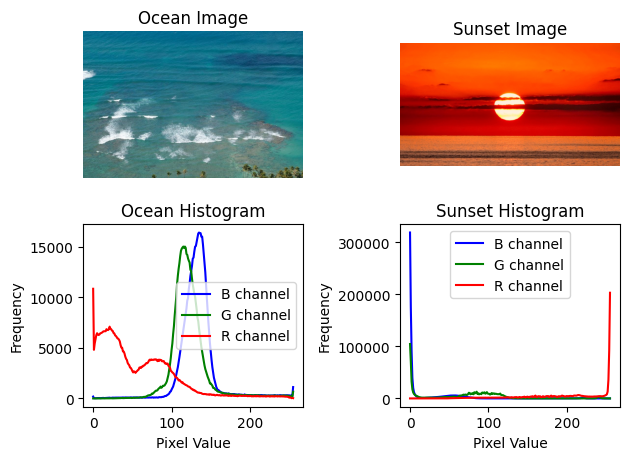

In [12]:
img = cv2.imread('ocean_colors.jpeg')
img2 = cv2.imread('sunset.jpg')

color = ('b','g','r')
# Top row: Images
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Ocean Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title('Sunset Image')
plt.axis('off')

plt.subplot(2, 2, 3)
for i, col in enumerate(color):
    hist = cv2.calcHist([img], [i], None, [256], [0,256])
    plt.plot(hist, color=col, label=f"{col.upper()} channel")
plt.title('Ocean Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 2, 4)
for i, col in enumerate(color):
    hist = cv2.calcHist([img2], [i], None, [256], [0,256])
    plt.plot(hist, color=col, label=f"{col.upper()} channel")
plt.title('Sunset Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

**Interpretation:**

**Blue Channel:**

High peak in the blue channel, especially in mid-to-high values (since ocean water and sky reflect lots of blue light).
Most pixels are in the cyan/blue range.

The blue channel is minimal, since there are almost no blue tones in the sunset scene.


**Green Channel:**

The green channel will also show significant activity, but less than blue. This is because ocean water is often a blend of blue and green, especially near shore or with vegetation under water.


The green channel supports the orange, with moderate values.

**Red Channel:**

The red channel will generally be lower, since there’s little red in the ocean scene, except for subtle reflections, sand, or brownish elements.

The red channel spikes high, especially at the top end, because of the glowing sun and the saturated sky.

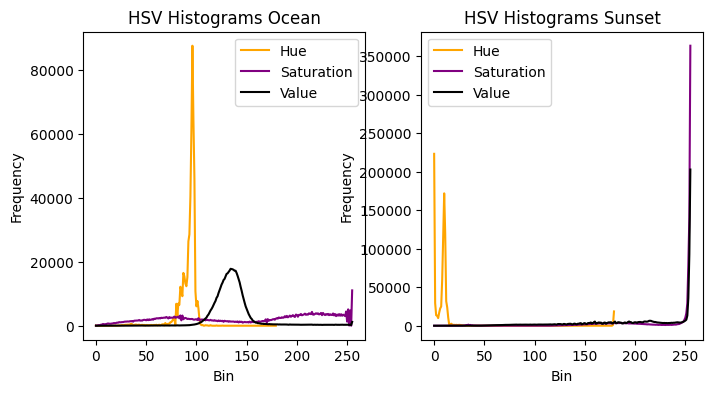

In [13]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h_hist = cv2.calcHist([img_hsv],[0],None,[180],[0,180])
s_hist = cv2.calcHist([img_hsv],[1],None,[256],[0,256])
v_hist = cv2.calcHist([img_hsv],[2],None,[256],[0,256])

img_hsv2 = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)
h_hist2 = cv2.calcHist([img_hsv2],[0],None,[180],[0,180])
s_hist2 = cv2.calcHist([img_hsv2],[1],None,[256],[0,256])
v_hist2 = cv2.calcHist([img_hsv2],[2],None,[256],[0,256])

plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.plot(h_hist, color='orange', label='Hue')
plt.plot(s_hist, color='purple', label='Saturation')
plt.plot(v_hist, color='black', label='Value')
plt.title('HSV Histograms Ocean')
plt.xlabel('Bin')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h_hist2, color='orange', label='Hue')
plt.plot(s_hist2, color='purple', label='Saturation')
plt.plot(v_hist2, color='black', label='Value')
plt.title('HSV Histograms Sunset')
plt.xlabel('Bin')
plt.ylabel('Frequency')
plt.legend()
plt.show()


###**3.2) Color moment**

In [14]:
from scipy.stats import skew

means = cv2.mean(img)[:3] #for each channel
stds = [np.std(img[:,:,i]) for i in range(3)]
skews = [skew(img[:,:,i].flatten()) for i in range(3)]

means2 = cv2.mean(img2)[:3]
stds2 = [np.std(img2[:,:,i]) for i in range(3)]
skews2 = [skew(img2[:,:,i].flatten()) for i in range(3)]

#Create pd dataframe
data = {
    'mean_B': [means[0], means2[0]],
    'mean_G': [means[1], means2[1]],
    'mean_R': [means[2], means2[2]],
    'std_B':  [stds[0],  stds2[0]],
    'std_G':  [stds[1],  stds2[1]],
    'std_R':  [stds[2],  stds2[2]],
    'skew_B': [skews[0], skews2[0]],
    'skew_G': [skews[1], skews2[1]],
    'skew_R': [skews[2], skews2[2]],
}

df = pd.DataFrame(data, index=['Ocean', 'Sunset'])
print(df)


            mean_B      mean_G     mean_R      std_B      std_G      std_R  \
Ocean   134.542391  123.237425   56.78672  24.600167  25.500955  47.295549   
Sunset   16.771660   62.207279  207.17421  33.056488  49.021609  53.766506   

          skew_B    skew_G    skew_R  
Ocean   1.397797  2.114176  1.297962  
Sunset  3.267501  0.487843 -0.984074  


**Interpretation**

Mean
*   High mean in B/G: likely ocean, sky
*   High mean in R: likely sunset

Skewness

*   Ocean: Most pixels have relatively low-to-mid values in each channel.
*   Sunset: Red channel has negative skew, confirming the image is mostly very red. Blue channel has high positive skew, indicating blue is almost absent except for a few scattered pixels. Green is near symmetric, indicating a more balanced distribution.



###**3.3) Dominant Color**

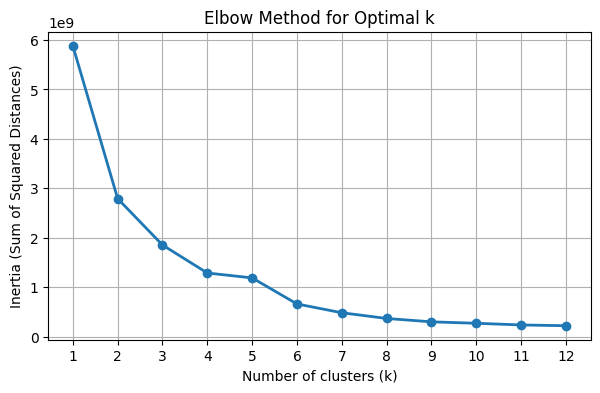

In [15]:
from sklearn.cluster import KMeans

# Load image and reshape for clustering
img = cv2.imread('ocean_colors.jpeg')
img = cv2.imread('sunset.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pixels = img_rgb.reshape(-1, 3)

# Elbow method: try different k values
inertia = []
K = range(1, 13)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixels)
    inertia.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(7, 4))
plt.plot(K, inertia, 'o-', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K)
plt.grid(True)
plt.show()

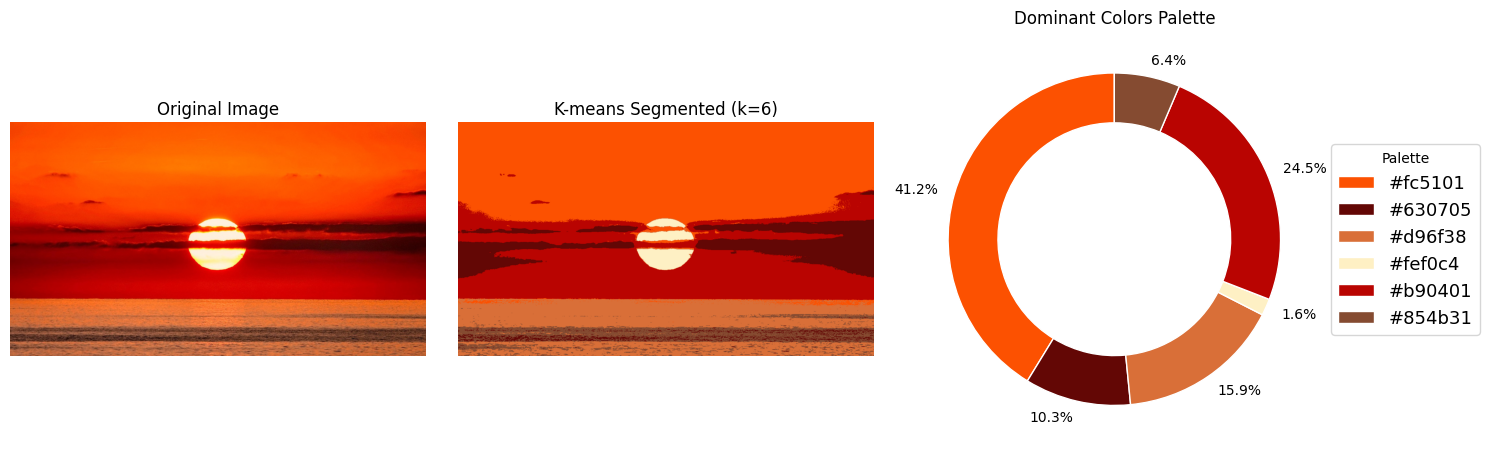

In [16]:
# Use k found by elbow
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)  # label of each pixel
palette = np.uint8(kmeans.cluster_centers_) #color of the cluster centers RGB
counts = np.bincount(labels) #number of pixel

# Create palette bar
palette_img = np.zeros((50, 300, 3), dtype=np.uint8)
step = 300 // k
for i, color in enumerate(palette):
    palette_img[:, i*step:(i+1)*step] = color

# Get percentages
total = counts.sum()
percentages = 100 * counts / total

# Convert palette to [0,1] for matplotlib (opencv from 0 to 255)
colors = [tuple(color/255) for color in palette]
hex_colors = ['#%02x%02x%02x' % tuple(color) for color in palette]

# Reconstruct clustered image
segmented = palette[labels].reshape(img_rgb.shape) #assign each pixel to its palette RGB, then reshape in 2D, not a flat array

# Show images: original, segmented, and palette
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(segmented)
plt.title(f'K-means Segmented (k={k})')
plt.axis('off')

plt.subplot(1,3,3)
wedges, texts = plt.pie(
    percentages,
    colors=colors,
    labels=[f"{p:.1f}%" for p in percentages],
    startangle=90,
    autopct=None,
    wedgeprops=dict(width=0.3, edgecolor='w')
)

# Legend with hex codes
plt.legend(wedges, hex_colors, title="Palette", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=13)

plt.title('Dominant Colors Palette')
plt.axis('off')

plt.tight_layout()
plt.show()

###**3.3) Shape features**

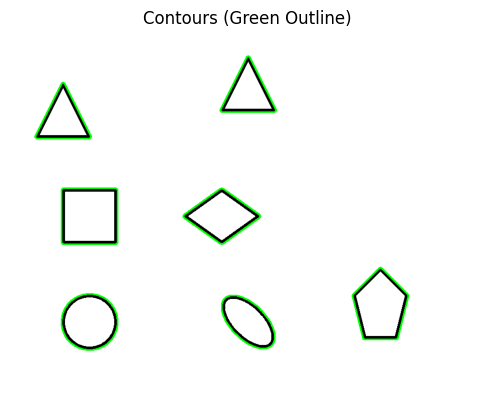

In [17]:
img = cv2.imread('shapes.png', 0)  # Black and white image with shapes

'''Be careful

Image has black shapes on a white background.

By default, cv2.findContours considers white pixels (255) as the foreground.
So after thresholding, the entire background is detected as one big object, and your shapes become “holes” in that object.
You need to invert the image
'''
img2 = cv2.bitwise_not(img.copy())
ret, thresh = cv2.threshold(img2, 110, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contour = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_contour, contours, -1, (0,255,0), 2)

plt.imshow(img_contour)
plt.title('Contours (Green Outline)')
plt.axis('off')
plt.show()

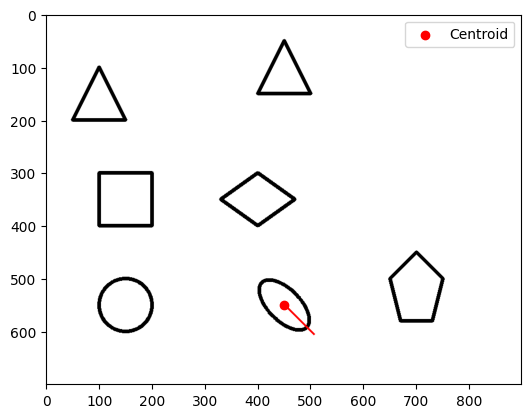

Angle: 0.7855717348723081
Area: 6538.0
Hu Moments: [ 1.93325367e-01  1.20369273e-02  5.16219701e-09  3.59487227e-10
  4.12393607e-20 -6.43004389e-12 -4.87974463e-19]


In [18]:
def get_orientation(contour):
    M = cv2.moments(contour)
    if M['m00'] == 0:
        return None  # Avoid division by zero

    # Calculate centroid
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])

    # Central moments
    mu20 = M['mu20'] / M['m00']
    mu02 = M['mu02'] / M['m00']
    mu11 = M['mu11'] / M['m00']

    # Orientation angle (radians)
    angle = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
    return cx, cy, angle, M
img = cv2.imread('shapes.png', 0)  # Black and white image with shapes

img2 = cv2.bitwise_not(img.copy())
ret, thresh = cv2.threshold(img2, 110, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contour = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

cnt = contours[0] #select a contour
cx, cy, angle, M=get_orientation(cnt)

length = 80  # Length of the orientation line
x2 = int(cx + length * np.cos(angle))
y2 = int(cy + length * np.sin(angle))
plt.scatter([cx], [cy], color='red', label='Centroid')

cv2.line(img_contour, (cx, cy), (x2, y2), (255,0,0), 3)
plt.imshow(img_contour)

plt.legend()
plt.show()

# Angle:
print(f"Angle: {angle}")


# Area:
area = cv2.contourArea(cnt)
print(f"Area: {area}")

# Hu Moments:
hu = cv2.HuMoments(M).flatten()
print("Hu Moments:", hu)

##**4) Feature extraction**

###**4.1) SIFT**

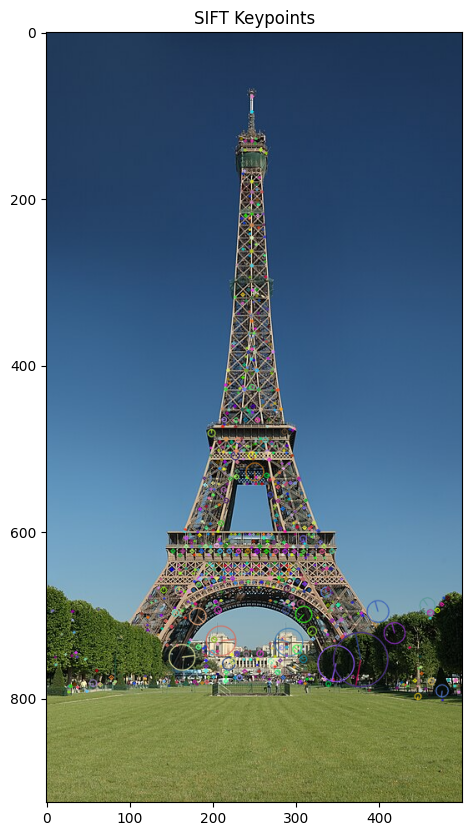

In [20]:
image = cv2.imread('Tour_Eiffel.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect SIFT keypoints
'''
nfeatures:
Maximum number of keypoints to retain.
(Default: 0 means unlimited)

nOctaveLayers:
Number of layers in each octave.
(Default: 3; affects the granularity of scale space search)

contrastThreshold:
Keypoints below this contrast are discarded (removes low-contrast points, e.g., in flat sky).
(Default: 0.04; increase to suppress weak keypoints)

edgeThreshold:
Threshold for filtering out edge-like keypoints (higher = less strict).
(Default: 10)

sigma:
Initial Gaussian blur sigma (for the first octave).
(Default: 1.6)
'''
sift = cv2.SIFT_create(contrastThreshold=0.1)

#sift.detect() function finds the keypoint in the images
keypoints, des = sift.detectAndCompute(gray,None)

# cv.drawKeyPoints() function which draws the small circles on the locations of keypoints.
image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

#

# Display the image with keypoints
plt.figure(figsize=(20, 10))
plt.title('SIFT Keypoints')
plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.show()

###**4.2) ORB**

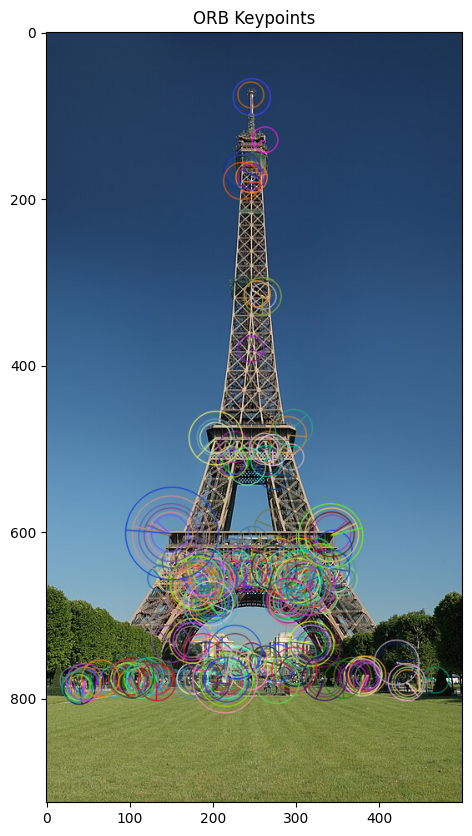

In [21]:
image = cv2.imread('Tour_Eiffel.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect SIFT keypoints
'''
nfeatures:
Maximum number of features to retain (default: 500).

scaleFactor:
Pyramid decimation ratio (default: 1.2).
(How much each image level is reduced compared to the previous one; smaller = more levels, more keypoints.)

nlevels:
Number of pyramid levels (default: 8).
(How many scales ORB will look for keypoints in.)

edgeThreshold:
Size of the border where features are not detected (default: 31).
(Larger value means more margin at the border.)

firstLevel:
Level of pyramid to put the source image to (default: 0).

WTA_K:
Number of points that produce each element of the oriented BRIEF descriptor (default: 2).

scoreType:
Type of score to rank features
(Default: cv2.ORB_HARRIS_SCORE, or use cv2.ORB_FAST_SCORE.)

patchSize:
Size of the patch used by the oriented BRIEF descriptor (default: 31).

fastThreshold:
Threshold for the FAST corner detector (default: 20).
(Lower value detects more features, possibly more noise.)
'''
orb = cv2.ORB_create(fastThreshold=100)

#sift.detect() function finds the keypoint in the images
keypoints, des = orb.detectAndCompute(gray,None)

# cv.drawKeyPoints() function which draws the small circles on the locations of keypoints.
image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the image with keypoints
plt.figure(figsize=(20, 10))
plt.title('ORB Keypoints')
plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.show()

## **5) Segmentation**
### **5.1) Threshold**

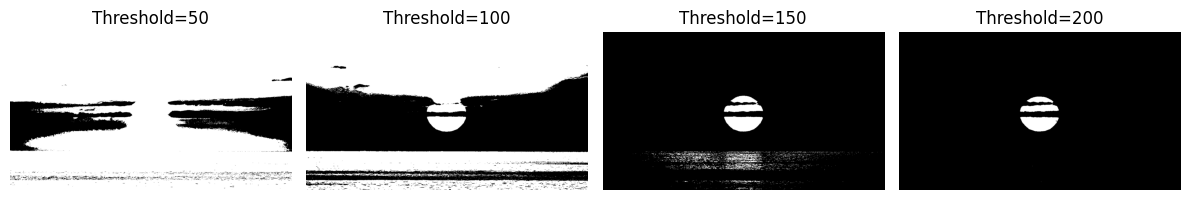

In [22]:
img = cv2.imread('sunset.jpg',0)
# Choose different threshold values
thresholds = [50, 100, 150, 200]

plt.figure(figsize=(12, 6))

for i, th in enumerate(thresholds):
    ret, thresh_img = cv2.threshold(img, th, 255, cv2.THRESH_BINARY)
    plt.subplot(1, len(thresholds), i+1)
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f'Threshold={th}')
    plt.axis('off')

plt.tight_layout()
plt.show()


### **5.2) Kmeans**

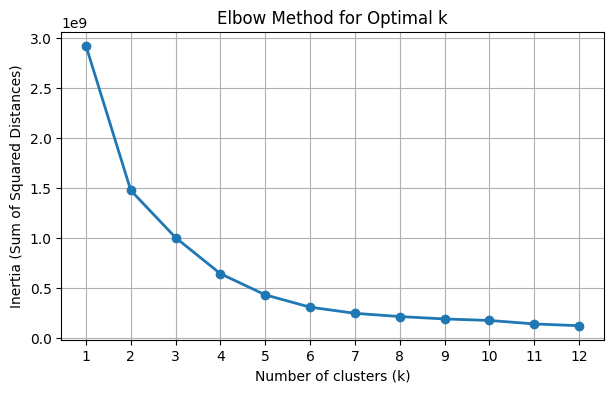

In [23]:
from sklearn.cluster import KMeans

# Load image and reshape for clustering
img = cv2.imread('Tour_Eiffel.jpg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
pixels = img_rgb.reshape(-1, 3)

# Elbow method: try different k values
inertia = []
K = range(1, 13)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixels)
    inertia.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(7, 4))
plt.plot(K, inertia, 'o-', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.xticks(K)
plt.grid(True)
plt.show()

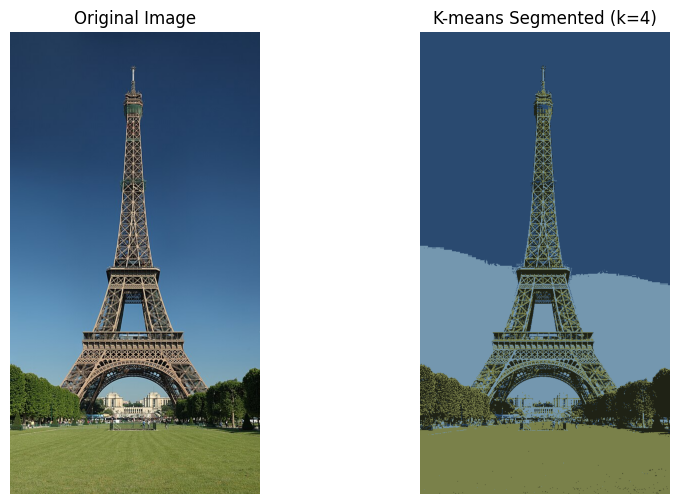

In [24]:
# Use k found by elbow
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)  # label of each pixel
palette = np.uint8(kmeans.cluster_centers_) #color of the cluster centers RGB
counts = np.bincount(labels) #number of pixel


# Convert palette to [0,1] for matplotlib (opencv from 0 to 255)
colors = [tuple(color/255) for color in palette]
hex_colors = ['#%02x%02x%02x' % tuple(color) for color in palette]

# Reconstruct clustered image
segmented = palette[labels].reshape(img_rgb.shape) #assign each pixel to its palette RGB, then reshape in 2D, not a flat array

# Show images: original, segmented, and palette
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(segmented)
plt.title(f'K-means Segmented (k={k})')
plt.axis('off')
plt.show()

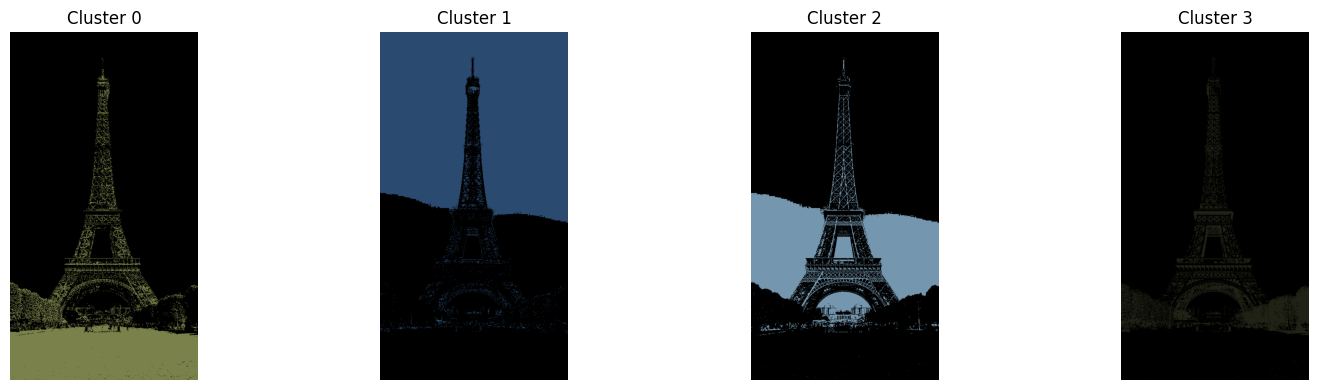

In [25]:
# Show each cluster as a separate mask
fig, axes = plt.subplots(1, k, figsize=(16, 4))
for kk in range(k):
    # Create a mask for current cluster
    mask = (labels == kk).reshape(img_rgb.shape[:2])
    component = np.zeros_like(img_rgb)
    component[mask] = kmeans.cluster_centers_[kk].astype(np.uint8)
    axes[kk].imshow(component)
    axes[kk].set_title(f'Cluster {kk}')
    axes[kk].axis('off')

plt.tight_layout()
plt.show()

###**Watershed segmentation**

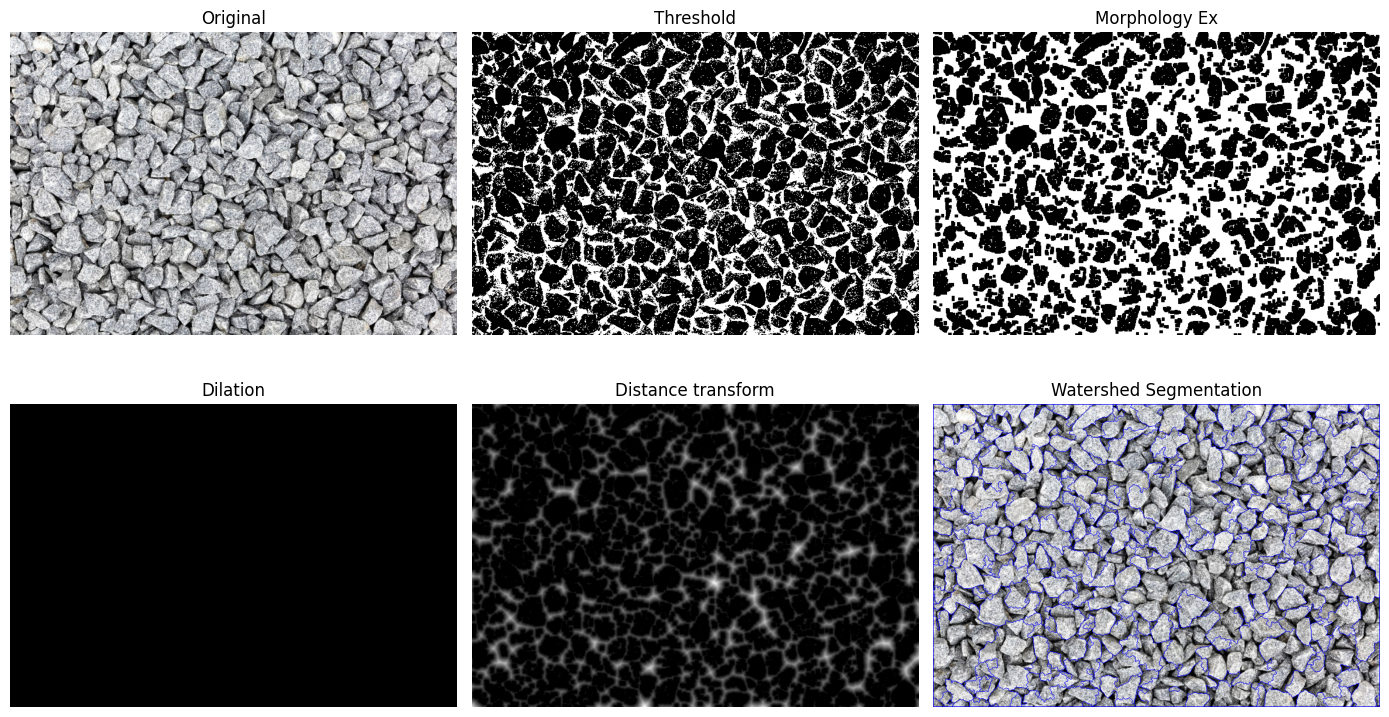

In [58]:
# Step 1: Read the image
#img = cv2.imread('euro_coins_mix.jpg')
img = cv2.imread('gravel.jpeg')

img_disp = img.copy()  # Keep a copy for display
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 2: Thresholding (Otsu's method)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
# Step 3: Remove noise

'''
Opening is just another name of erosion followed by dilation.
It is useful in removing noise, as we explained above. Here we use the function,

Closing is reverse of Opening, Dilation followed by Erosion.
It is useful in closing small holes inside the foreground objects, or small black points on the object.
'''

kernel = np.ones((3,3), np.uint8)
#nonoise = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
nonoise = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)


# Step 4: Dilatation
'''
This operations consists of convoluting an image A with some kernel (B), which can have any shape or size, usually a square or circle.

The kernel B has a defined anchor point, usually being the center of the kernel.
'''
kernel2 = np.ones((9,9), np.uint8)
sure_bg = cv2.dilate(nonoise, kernel2, iterations=40)

#Sure background: Regions definitely not coins (outside), found by dilation.


# Step 5: Distance transform
'''
The idea is to create a border as far as possible from the centers of the overlapping objects.
For this, we will use the method called a distance transform.
It is an operator that generally takes binary images as inputs and pixel intensities of the points inside
the foreground regions are replaced by their distance to the nearest pixel with zero intensity.

we can conclude that pixels closest to the center of our object will have a larger distance transform value.

'''

dist_transform = cv2.distanceTransform(nonoise, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.2*dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
#Sure foreground: Regions you are confident are coins (centers), found via distance transform.

# 6. Find unknown region
unknown = cv2.subtract(sure_bg, sure_fg)
#Unknown: Between sure foreground and background—Watershed will resolve these.

# Step 7: Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # Background is 1, objects >= 2
markers[unknown == 255] = 0

#Markers: Unique integer labels given to each region—these “seed” the segmentation.

# Step 8: Apply Watershed
markers = cv2.watershed(img, markers)
img_disp[markers == -1] = [255, 0, 0]  # Mark boundaries in red

#Watershed: Floods out from each marker, building boundaries (red lines) where regions meet.


# Show steps for better understanding
plt.figure(figsize=(14,8))
plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')
plt.subplot(2,3,2)
plt.imshow(thresh, cmap='gray')
plt.title('Threshold')
plt.axis('off')
plt.subplot(2,3,3)
plt.imshow(nonoise, cmap='gray')
plt.title('Morphology Ex')
plt.axis('off')
plt.subplot(2,3,4)
plt.imshow(sure_bg, cmap='gray')
plt.title('Dilation')
plt.axis('off')
plt.subplot(2,3,5)
plt.imshow(dist_transform, cmap='gray')
plt.title('Distance transform')
plt.axis('off')
plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(img_disp, cv2.COLOR_BGR2RGB))
plt.title('Watershed Segmentation')
plt.axis('off')
plt.tight_layout()
plt.show()
